In [4]:
import os
GPUS_TO_USE = "0,4" 
os.environ["CUDA_VISIBLE_DEVICES"] = GPUS_TO_USE

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, Masking
from scipy.interpolate import UnivariateSpline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import keras
import itertools
from tensorflow.keras.callbacks import EarlyStopping
from datetime import datetime, timedelta
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')

print(f"\nĐang cấu hình sử dụng GPU: {GPUS_TO_USE}")
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"-> Đã tìm thấy {len(gpus)} GPU khả dụng sau khi lọc.")
        print(f"-> Danh sách thiết bị: {[g.name for g in gpus]}")
        print("-> Đã bật chế độ 'Memory Growth' (dùng VRAM vừa đủ).")
    except RuntimeError as e:
        print(f"Lỗi cấu hình GPU: {e}")
else:
    print("-> Không tìm thấy GPU nào (hoặc đã chọn chế độ CPU). Code sẽ chạy trên CPU.")


Đang cấu hình sử dụng GPU: 0,4
-> Đã tìm thấy 2 GPU khả dụng sau khi lọc.
-> Danh sách thiết bị: ['/physical_device:GPU:0', '/physical_device:GPU:1']
-> Đã bật chế độ 'Memory Growth' (dùng VRAM vừa đủ).


In [5]:
# Define helper functions
def flattern(p):
    pred_y_matrix = [[] for _ in range(len(p[0]))]
    for pp in p:
        a = pp.tolist()
        for m in range(len(a)):
            pred_y_matrix[m] += a[m]
    return pred_y_matrix

# Interpolate the NaN values
def interpolate(data, mask):
    temp = [list(dd) for dd in data]
    d = []
    for i in range(len(temp)):
        for j in range(len(temp[i])):
            if temp[i][j] == mask:
                temp[i][j] = float("NaN")
        df = pd.Series(temp[i]).interpolate(method='linear')
        d.append(df.tolist())
    return d

def split_train(Int_dat, Norm_dat, T1, T2, T3, Stride, start, end, data_name):
    length = len(Int_dat[0])
    s = int(length * start)
    e = int(length * end)
    Train = [N[:s] for N in Norm_dat] 
    Test = [M[s:e] for M in Int_dat]
    
    print('Training Data Length: ', len(Train), 'X', len(Train[0]))
    print('Test Data Length: ', len(Test), 'X', len(Test[0]))
    
    train_x, train_y = data_split(Train, T1, T2, T3, Stride)
    test_x, test_y = data_split(Test, T1, T2, T3, Stride)
    return train_x, train_y, test_x, test_y

def data_split(dat, train_hour, test_hour, predict_position, stride):
    x, y = [], []
    period = train_hour + predict_position + test_hour
    if len(dat) == 0 or len(dat[0]) < period:
        return np.array([]), np.array([])
        
    i = 0
    while i + period <= len(dat[0]):
        x_temp = []
        y_temp = []
        for j in range(len(dat)):
            x_temp.append(dat[j][i:i + train_hour])
            y_temp.append(dat[j][i + train_hour + predict_position:i + train_hour + predict_position + test_hour])
        x.append(x_temp)
        y.append(y_temp)
        i += stride
    return np.array(x), np.array(y)

def data_normalize(Dat):
    new_dat = []
    scaling_params = []
    for d in Dat:
        valid_vals = [val for val in d if val != -1]
        if not valid_vals: # Handle empty data case
            min_val, max_val = 0, 1
        else:
            min_val = np.min(valid_vals)
            max_val = np.max(valid_vals)
            
        scaling_params.append((min_val, max_val))
        
        temp = []
        for val in d:
            if val == -1:
                temp.append(val)
            else:
                # Min-max scaling
                norm = (val - min_val) / (max_val - min_val) if max_val != min_val else 0
                temp.append(norm)
        new_dat.append(temp)
    return new_dat, scaling_params

def load_and_align_data(sensor_files, variables):
    data = []
    variable_names = []
    time_index = None

    for sensor_name, file_path in sensor_files.items():
        try:
            df = pd.read_csv(file_path)
            df.columns = [c.strip() for c in df.columns]
            
            if 'ts' not in df.columns:
                print(f"Lỗi: Không tìm thấy cột 'ts' trong file {file_path}")
                continue
                
            df['ts'] = pd.to_datetime(df['ts'])
            df.set_index('ts', inplace=True)
            df.sort_index(inplace=True) 
            
            df.fillna(-1, inplace=True)

            # Align time index 
            if time_index is None:
                time_index = df.index
            else:
                time_index = time_index.intersection(df.index)
                
        except Exception as e:
            print(f"Lỗi khi đọc file {file_path}: {e}")
            return [], [], None

    if time_index is None or len(time_index) == 0:
        print("Không có dữ liệu hoặc dữ liệu thời gian không hợp lệ.")
        return [], [], None

    for sensor_name, file_path in sensor_files.items():
        df = pd.read_csv(file_path)
        df.columns = [c.strip() for c in df.columns]
        df['ts'] = pd.to_datetime(df['ts'])
        df.set_index('ts', inplace=True)
        # Remove duplicates index if any
        df = df[~df.index.duplicated(keep='first')]
        
        df.fillna(-1, inplace=True)

        for var in variables:
            if var in df.columns:
                df_aligned = df.reindex(time_index, fill_value=-1)
                aligned_data = df_aligned[var].tolist()
                data.append(aligned_data)
                variable_names.append(f"{sensor_name}_{var}")
            else:
                print(f"Cảnh báo: Biến '{var}' không tìm thấy trong file.")

    return data, variable_names, time_index

def stacked_LSTM(X, Y):
    if X.shape[0] == 0:
        print("Không có dữ liệu huấn luyện!")
        return None, None
        
    time_step = X.shape[1]
    input_dim = X.shape[2]
    out = Y.shape[2]
    model = Sequential()
    model.add(Masking(mask_value=-1., input_shape=(time_step, input_dim)))
    model.add(Bidirectional(LSTM(32, activation='relu', return_sequences=True)))
    model.add(Dense(out))
    model.compile(loss='mean_absolute_error', optimizer=keras.optimizers.Adam(learning_rate=1e-5))

    # Add early stopping
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    hist = model.fit(X, Y, epochs=5, validation_split=0.2, verbose=1, batch_size=10, callbacks=[early_stopping])
    model.summary()
    return model, hist

def SP_Learner(data, train_time, predict_time, predict_position, Stride, start, end, data_name):
    norm_dat, scaling_params = data_normalize(data)
    norm_int_dat = interpolate(norm_dat, -1)
    train_x, train_y, test_x, test_y = split_train(norm_int_dat, norm_dat, train_time, predict_time, predict_position, Stride, start, end, data_name)
    
    if len(train_x) == 0:
        print("Không đủ dữ liệu để tạo batch huấn luyện. Hãy giảm train_time hoặc kiểm tra lại dữ liệu.")
        return None, None, None, None

    model, hist = stacked_LSTM(train_x, train_y)
    if model is None:
        return None, None, None, None
        
    pred_y = model.predict(test_x, verbose=1)
    return pred_y, test_y, model, scaling_params

def evaluate_model(pred_y, test_y, variable_names, scaling_params, time_index, start):
    results = {}
    
    start_idx = int(len(time_index) * start)
    if len(pred_y) == 0:
        return {}

    for i, var_name in enumerate(variable_names):
        min_val, max_val = scaling_params[i]

        # Inverse transform
        pred_original = pred_y[:,i,0] * (max_val - min_val) + min_val
        true_original = test_y[:,i,0] * (max_val - min_val) + min_val
        
        # Tính toán metrics
        mae = mean_absolute_error(true_original, pred_original)
        rmse = np.sqrt(mean_squared_error(true_original, pred_original))
        r2 = r2_score(true_original, pred_original)
        mape = mean_absolute_percentage_error(true_original, pred_original) * 100

        results[var_name] = {
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2,
            'MAPE': mape,
            'Best Shift': 0 
        }
        
        print(f"{var_name} - MAE: {mae:.4f}, RMSE: {rmse:.4f}, R2: {r2:.4f}")
        
        # Plotting
        plt.figure(figsize=(12, 6))
        plt.plot(true_original, label='Actual')
        plt.plot(pred_original, label='Predicted')
        plt.title(f'Prediction vs Actual for {var_name}')
        plt.legend()
        plt.show()

    return results


Processing Hospital_Sensor from file ./Dataset/IAQ Baqubah Teaching Hospital .csv


Variables loaded: ['Hospital_Sensor_PM2.5']
Data points: 523524
Training Data Length:  1 X 418819
Test Data Length:  1 X 104705


/home/24minh.ntn/miniconda3/envs/minh-domain/lib/python3.13/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
6698/6698 ━━━━━━━━━━━━━━━━━━━━ 176s 24ms/step - loss: 0.0827 - val_loss: 0.0779
Epoch 2/5
6698/6698 ━━━━━━━━━━━━━━━━━━━━ 103s 10ms/step - loss: 0.0588 - val_loss: 0.0707
Epoch 3/5
6698/6698 ━━━━━━━━━━━━━━━━━━━━ 135s 20ms/step - loss: 0.0553 - val_loss: 0.0679
Epoch 4/5
6698/6698 ━━━━━━━━━━━━━━━━━━━━ 135s 19ms/step - loss: 0.0536 - val_loss: 0.0660
Epoch 5/5
6698/6698 ━━━━━━━━━━━━━━━━━━━━ 174s 26ms/step - loss: 0.0524 - val_loss: 0.0645


Model: "sequential_1"

...

 Trainable params: 55,178 (215.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 110,358 (431.09 KB)

2025-11-29 00:44:47.047384: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


654/654 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step
Hospital_Sensor_PM2.5 - MAE: 15.5530, RMSE: 21.7732, R2: 0.8328


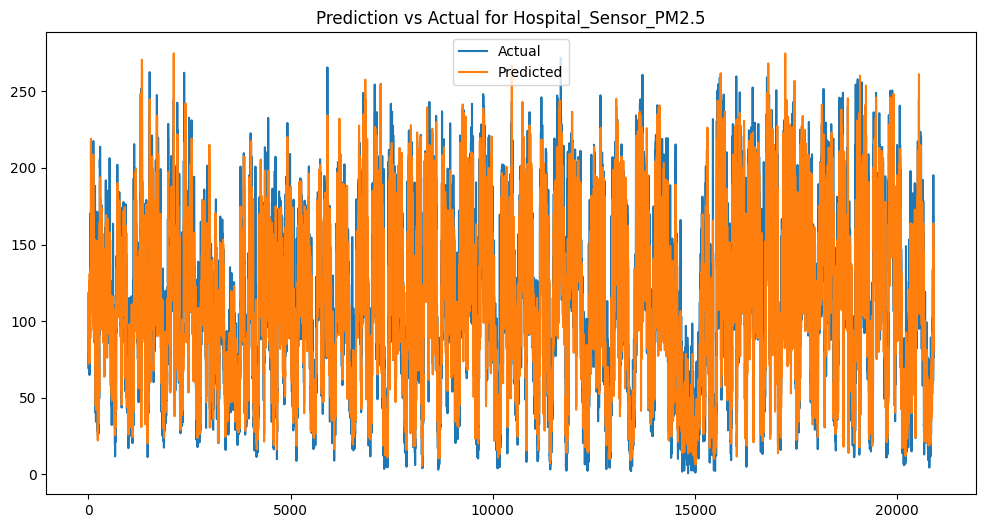


Final Results Summary:
Hospital_Sensor - Hospital_Sensor_PM2.5: MAE=15.5530, R2=0.8328


In [6]:
train_time = 180      # Độ dài chuỗi huấn luyện (giảm xuống 60 phút để chạy nhanh hơn test)
predict_time = 10    # Độ dài chuỗi dự báo
predict_position = 0 # Khoảng cách giữa train và predict (0 = dự báo ngay tiếp theo)
stride = 5           # Bước nhảy cửa sổ trượt
start = 0.8          # Tỉ lệ train/test (80% train)
end = 1.0

file_name = './Dataset/IAQ Baqubah Teaching Hospital .csv' 

# Các cột có thể chọn: 'CO2', 'TVOC', 'PM10', 'PM2.5', 'eCO2', 'CO', 'Air Quality', 'LDR', 'O3', 'Temp', 'Hum'
variables = ['PM2.5'] 

all_sensors = {
    'Hospital_Sensor': file_name
}

single_sensor_results = {}

for sensor_name, file_path in all_sensors.items():
    print(f"\n{'='*50}")
    print(f"Processing {sensor_name} from file {file_path}")
    
    # Load Data
    data, var_names, time_index = load_and_align_data({sensor_name: file_path}, variables)
    
    if not data:
        print("Không tải được dữ liệu. Dừng.")
        continue
        
    print(f"Variables loaded: {var_names}")
    print(f"Data points: {len(data[0])}")

    # Train Model
    pred_y, test_y, model, scaling_params = SP_Learner(
        data, train_time, predict_time, predict_position, stride, start, end, sensor_name
    )
    
    # Evaluate
    if model is not None:
        sensor_results = evaluate_model(pred_y, test_y, var_names, scaling_params, time_index, start)
        single_sensor_results[sensor_name] = sensor_results

# Tổng hợp kết quả
print("\nFinal Results Summary:")
for sensor, res in single_sensor_results.items():
    for var, metrics in res.items():
        print(f"{sensor} - {var}: MAE={metrics['MAE']:.4f}, R2={metrics['R²']:.4f}")